In [ ]:
!pip install statsbombpy
from google.colab import data_table
data_table.DataTable.max_columns = 92

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

# descarcarea evenimentelor dureaza cateva minute, asa ca le salvam intr-un fisier cache
# si le citim de acolo la rularile urmatoare (cateva secunde)
# in Colab, cache-ul se pune in Google Drive, altfel s-ar sterge la inchiderea sesiunii
FORTEAZA_DESCARCARE = False  # True pentru a descarca din nou datele de la StatsBomb
if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount('/content/drive')
  director_cache = '/content/drive/MyDrive/statsbomb_cache'
else:
  director_cache = 'statsbomb_cache'
os.makedirs(director_cache, exist_ok=True)
fisier_cache = os.path.join(director_cache, 'evenimente_wc2018_wc2022.parquet')

if os.path.exists(fisier_cache) and not FORTEAZA_DESCARCARE:
  evenimente_totale = pd.read_parquet(fisier_cache)
  print(f'Evenimente incarcate din cache: {fisier_cache}')
else:
  from statsbombpy import sb
  competitii = sb.competitions()
  #display(competitii.head(40))
  #World Cup 2022
  meciuri_2022 = sb.matches(competition_id=43, season_id=106)
  #World Cup 2018
  meciuri_2018 = sb.matches(competition_id=43, season_id=3)
  meciuri = pd.concat([meciuri_2018, meciuri_2022])
  #meciuri.head(10)
  lista_match_id = meciuri['match_id'].tolist()
  toate_evenimentele = []
  for match_id in lista_match_id:
    evenimente = sb.events(match_id = match_id)
    evenimente = evenimente.dropna(subset = ['player'])
    toate_evenimentele.append(evenimente)
  evenimente_totale = pd.concat(toate_evenimentele)
  evenimente_totale.to_parquet(fisier_cache)
  print(f'Evenimente descarcate si salvate in: {fisier_cache}')
# unii jucatori au nume scrise diferit in 2018 si 2022 (ex. Phil Foden / Philip Foden),
# asa ca folosim un singur nume pentru fiecare player_id (cel mai des intalnit)
nume_jucatori = evenimente_totale.groupby('player_id')['player'].agg(lambda nume: nume.value_counts().index[0])
evenimente_totale['player'] = evenimente_totale['player_id'].map(nume_jucatori)
evenimente_totale['substitution_replacement'] = (
    evenimente_totale['substitution_replacement_id'].map(nume_jucatori)
    .fillna(evenimente_totale['substitution_replacement'])
)
#display(evenimente_totale.info())

In [ ]:
# construirea tabelului de statistici pentru fiecare jucator
actiuni_relevante = [
    'Pass', 'Shot', 'Duel', 'Clearance', 'Interception',
    'Foul Committed', 'Dribble', 'Block', 'Pressure',
    'Foul Won', 'Dispossessed', 'Ball Recovery', 'Goal Keeper'
]
evenimente1 = evenimente_totale[evenimente_totale['type'].isin(actiuni_relevante)]
actiuni_separate = pd.get_dummies(evenimente1['type'], dtype = int)
actiuni_jucatori = pd.concat([evenimente1[['player_id', 'player']], actiuni_separate], axis=1)
statistici_finale = actiuni_jucatori.groupby(['player_id', 'player']).sum().reset_index()
#display(statistici_finale.sort_values(by=["Dribble"]))

In [ ]:
# adaugare statistici proprii (centrari, deposedari, xG, xA)
import numpy as np
centrari = evenimente_totale[(evenimente_totale['type'] == 'Pass') & (evenimente_totale['pass_cross'] == True)]
total_centrari = centrari.groupby(['player_id', 'player']).size().reset_index(name='Cross')

tackles = evenimente_totale[(evenimente_totale['type'] == 'Duel') & (evenimente_totale['duel_type'] == 'Tackle')]
total_tackles = tackles.groupby(['player_id', 'player']).size().reset_index(name='Tackle')

suturi = evenimente_totale[evenimente_totale['type'] == 'Shot'].copy()
xg_jucatori = suturi.groupby(['player_id', 'player'])['shot_statsbomb_xg'].sum().reset_index()
xg_jucatori.rename(columns={'shot_statsbomb_xg': 'xG'}, inplace=True)

pase_cheie = evenimente_totale[(evenimente_totale['type'] == 'Pass') & (evenimente_totale['pass_assisted_shot_id'].notnull())].copy()
xg_suturi = suturi[['id', 'shot_statsbomb_xg']].rename(columns={
    'id': 'shot_id',
    'shot_statsbomb_xg': 'xA_value'
})
pase_cheie = pase_cheie.merge(xg_suturi, left_on='pass_assisted_shot_id', right_on='shot_id', how='left')

xa_jucatori = pase_cheie.groupby(['player_id', 'player'])['xA_value'].sum().reset_index()
xa_jucatori.rename(columns={'xA_value': 'xA'}, inplace=True)

pase = evenimente_totale[evenimente_totale['type'] == 'Pass'].copy()
lungime_pase = pase.groupby(['player_id', 'player'])['pass_length'].mean().reset_index()
lungime_pase.rename(columns={'pass_length': 'avg_pass_length'}, inplace=True)

suturi = evenimente_totale[evenimente_totale['type'] == 'Shot'].copy()
suturi = suturi.dropna(subset=['location'])

coordonate = pd.DataFrame(suturi['location'].tolist(), index=suturi.index)
suturi['X'] = coordonate[0]
suturi['Y'] = coordonate[1]
suturi['shot_distance'] = np.sqrt((120 - suturi['X'])**2 + (40 - suturi['Y'])**2)
distanta_sut = suturi.groupby(['player_id', 'player'])['shot_distance'].mean().reset_index()
distanta_sut.rename(columns={'shot_distance': 'avg_shot_distance'}, inplace=True)


statistici_finale = statistici_finale.merge(total_centrari, on=['player_id', 'player'], how='left')
statistici_finale = statistici_finale.merge(total_tackles, on=['player_id', 'player'], how='left')
statistici_finale = statistici_finale.merge(xg_jucatori, on=['player_id', 'player'], how='left')
statistici_finale = statistici_finale.merge(xa_jucatori, on=['player_id', 'player'], how='left')
statistici_finale = statistici_finale.merge(lungime_pase, on=['player_id', 'player'], how='left')
statistici_finale = statistici_finale.merge(distanta_sut, on=['player_id', 'player'], how='left')

# tabel pentru valori lipsa
Nr_valori_lipsa = statistici_finale.isna().sum()
Procent_valori_lipsa = statistici_finale.isna().sum() / len(statistici_finale)
valori_lipsa = pd.concat([Nr_valori_lipsa, Procent_valori_lipsa], axis = 1, keys = ['Nr valori lipsa', 'Procent'])
valori_lipsa['Procent'] = valori_lipsa['Procent'].map('{:.2%}'.format)
print(valori_lipsa)

# unde nu exista statistici, inlocuim cu 0
statistici_finale = statistici_finale.fillna(0)

                   Nr valori lipsa Procent
player_id                        0   0.00%
player                           0   0.00%
Ball Recovery                    0   0.00%
Block                            0   0.00%
Clearance                        0   0.00%
Dispossessed                     0   0.00%
Dribble                          0   0.00%
Duel                             0   0.00%
Foul Committed                   0   0.00%
Foul Won                         0   0.00%
Goal Keeper                      0   0.00%
Interception                     0   0.00%
Pass                             0   0.00%
Pressure                         0   0.00%
Shot                             0   0.00%
Cross                          456  41.68%
Tackle                         286  26.14%
xG                             367  33.55%
xA                             447  40.86%
avg_pass_length                  5   0.46%
avg_shot_distance              367  33.55%


In [ ]:
# gasirea minutelor fiecarui jucator si scoaterea celor cu mai putin de 90 de minute
minute_jucate = evenimente_totale.dropna(subset = ['player'])[['match_id', 'player_id', 'player']].drop_duplicates()
durata_meci = evenimente_totale.groupby('match_id')['minute'].max().reset_index()
durata_meci.rename(columns={'minute': 'match_length'}, inplace=True)
minute_jucate = minute_jucate.merge(durata_meci, on = 'match_id', how = 'left')
#display(minute_jucate.sort_values(by=["match_length"]))
schimbari = evenimente_totale[evenimente_totale['type'] == 'Substitution']
#display(schimbari)

intrate = schimbari[['match_id', 'substitution_replacement', 'minute']].rename(
    columns={'substitution_replacement': 'player', 'minute': 'minute_on'}
)

iesite = schimbari[['match_id', 'player', 'minute']].rename(
    columns={'minute': 'minute_off'}
)
minute_jucate = minute_jucate.merge(intrate, on=['match_id', 'player'], how='left')
minute_jucate['minute_on'] = minute_jucate['minute_on'].fillna(0)
minute_jucate = minute_jucate.merge(iesite, on=['match_id', 'player'], how='left')
minute_jucate['minute_off'] = minute_jucate['minute_off'].fillna(minute_jucate['match_length'])
minute_jucate['minute_jucate'] = minute_jucate['minute_off'] - minute_jucate['minute_on']
total_minute = minute_jucate.groupby(['player_id', 'player'])['minute_jucate'].sum().reset_index()
#display(total_minute.sort_values(by = ['player']))



In [ ]:
# Normalizarea P90 (per 90 minute)
if 'minute_jucate' not in statistici_finale.columns:
  statistici_finale = statistici_finale.merge(total_minute, on=['player_id', 'player'], how='left')
statistici_filtrate = statistici_finale[statistici_finale['minute_jucate'] >= 90].copy()
#display(statistici_filtrate.sort_values(by=['minute_jucate']))
actiuni_p90 = [
    'Pass', 'Shot', 'Duel', 'Clearance', 'Interception',
    'Foul Committed', 'Dribble', 'Block', 'Pressure',
    'Foul Won', 'Dispossessed', 'Ball Recovery',
    'Cross', 'Tackle', 'xG', 'xA', 'Goal Keeper'
]
for actiune in actiuni_p90:
  nume_p90 = f"{actiune}_p90"
  statistici_filtrate[nume_p90] = (
            (statistici_filtrate[actiune] / statistici_filtrate['minute_jucate']) * 90
        ).round(2)
#display(statistici_filtrate.sort_values(by=['Pass_p90']))

In [ ]:
# crearea unui tabel separat p90
coloane_p90 = [col for col in statistici_filtrate.columns if 'p90' in col]
tabel_p90 = statistici_filtrate[['player', 'minute_jucate', 'player_id', 'avg_pass_length', 'avg_shot_distance'] + coloane_p90]
#display(tabel_p90.sort_values(by=['Pass_p90']))

In [ ]:
# gasirea pozitiei fiecarui jucator
from sklearn.preprocessing import LabelEncoder
pozitii_meciuri = evenimente_totale.dropna(subset = ['player', 'position'])
pozitii = pozitii_meciuri.groupby(['player_id', 'player', 'position']).size().reset_index(name = 'frecventa')
pozitii = pozitii.sort_values(by = ['player_id', 'frecventa'], ascending = [True, False])
pozitii_principale = pozitii.groupby(['player_id', 'player']).first().reset_index()
pozitii_principale = pozitii_principale.drop(columns = ['frecventa'])

#un jucator are pozitia substitute, il schimb manual
predrag = 'Predrag Rajković'
pozitia_corecta = 'Goalkeeper'
pozitii_principale.loc[pozitii_principale['player'] == predrag, 'position'] = pozitia_corecta

#PRIMA versiune a dictionarului, scor aproximativ de 0.78 la metrici, doar ca se poate crea confuzie
#(fundasii laterali sunt mai aproape de mijlocasi decat de fundasii centrali de ex)

#dictionar_pozitii_detaliat = {
#    'Goalkeeper': 'Portar',
#   'Center Back': 'Fundas', 'Left Back': 'Fundas', 'Left Center Back': 'Fundas', 'Left Wing Back': 'Fundas', 'Right Back': 'Fundas', 'Right Center Back': 'Fundas',
#   'Right Wing Back': 'Fundas',
#
#   'Center Attacking Midfield': 'Mijlocas', 	'Center Defensive Midfield': 'Mijlocas', 'Left Attacking Midfield': 'Mijlocas', 'Left Center Midfield': 'Mijlocas',
#   'Left Defensive Midfield': 'Mijlocas', 'Left Midfield': 'Mijlocas', 'Right Attacking Midfield': 'Mijlocas', 'Right Center Midfield': 'Mijlocas',
#   'Right Defensive Midfield': 'Mijlocas', 'Right Midfield': 'Mijlocas',
#
#   'Center Forward': 'Atacant', 'Left Center Forward': 'Atacant', 'Left Wing': 'Atacant', 'Right Center Forward': 'Atacant', 'Right Wing': 'Atacant',
#}

dictionar_pozitii_detaliat = {
    'Goalkeeper': 'Portar',

    'Center Back': 'Fundas', 'Left Center Back': 'Fundas', 'Right Center Back': 'Fundas',

    'Left Back': 'Fundas Lateral', 'Right Back': 'Fundas Lateral',
    'Left Wing Back': 'Fundas Lateral', 'Right Wing Back': 'Fundas Lateral',

    'Center Defensive Midfield': 'Mijlocas', 'Center Midfield': 'Mijlocas',
    'Left Defensive Midfield': 'Mijlocas', 'Right Defensive Midfield': 'Mijlocas',

    'Left Midfield': 'Mijlocas Ofensiv', 'Right Midfield': 'Mijlocas Ofensiv',
    'Center Attacking Midfield': 'Mijlocas Ofensiv',
    'Left Attacking Midfield': 'Mijlocas Ofensiv', 'Right Attacking Midfield': 'Mijlocas Ofensiv',
    'Secondary Striker': 'Mijlocas Ofensiv',
    'Left Wing': 'Mijlocas Ofensiv', 'Right Wing': 'Mijlocas Ofensiv',

    'Center Forward': 'Varf', 'Left Center Forward': 'Mijlocas Ofensiv', 'Right Center Forward': 'Mijlocas Ofensiv',

}


pozitii_principale['target_position'] = pozitii_principale['position'].map(dictionar_pozitii_detaliat).fillna('Mijlocas')
#display(pozitii_principale.sort_values(by = ['target_position']))

dataset_final = tabel_p90.merge(pozitii_principale[['player_id', 'player', 'target_position']], on=['player_id', 'player'], how='inner')
dataset_final['Defensive_Work_Ratio'] = (dataset_final['Tackle_p90'] + dataset_final['Interception_p90'] + dataset_final['Ball Recovery_p90']) / (dataset_final['Pass_p90'] + 1)
dataset_final['xG_to_xA_Ratio'] = dataset_final['xG_p90'] / (dataset_final['xA_p90'] + 0.01)
dataset_final['Touches_per_Shot'] = (dataset_final['Pass_p90'] + dataset_final['Dribble_p90'] + dataset_final['Duel_p90']) / (dataset_final['Shot_p90'] + 1)
#dataset_final['xG_to_xA_Ratio_Squared'] = dataset_final['xG_to_xA_Ratio'] ** 2
# fiecare jucator trebuie sa apara o singura data (numele sunt unificate in celula de incarcare)
assert not dataset_final['player_id'].duplicated().any()

# codificarea pozitiilor
encoder = LabelEncoder()
dataset_final['encoded_position'] = encoder.fit_transform(dataset_final['target_position'])

#dataset_afisare = dataset_final.drop(columns = ['avg_shot_distance', 'avg_pass_length', 'Clearance_p90', 'Interception_p90', 'Dribble_p90', 'Pressure_p90',
#                                                'Dispossessed_p90', 'Ball Recovery_p90']).copy()

display(dataset_final.sort_values(by = 'Pass_p90'))

,player,minute_jucate,player_id,avg_pass_length,avg_shot_distance,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,...,Cross_p90,Tackle_p90,xG_p90,xA_p90,Goal Keeper_p90,target_position,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot,encoded_position
519,Luka Jović,146.0,6319.0,17.192669,16.543343,6.16,1.23,1.23,0.00,0.62,...,0.62,0.00,0.04,0.04,0.0,Mijlocas Ofensiv,0.086592,0.800000,3.313901,3
816,Mohammad Hossein Kanani Zadegan,157.0,124175.0,31.825809,0.000000,6.31,0.00,0.00,0.57,1.15,...,0.00,0.00,0.00,0.00,0.0,Fundas,0.157319,0.000000,6.310000,0
736,Ui-Jo Hwang,124.0,29966.0,12.256590,11.423660,7.98,0.73,11.61,0.00,0.00,...,0.00,0.00,0.23,0.00,0.0,Varf,0.161470,23.000000,11.745665,5
743,Daizen Maeda,180.0,30628.0,18.513066,9.223378,9.00,1.00,6.00,0.00,1.00,...,0.50,1.50,0.27,0.00,0.0,Varf,0.450000,27.000000,7.500000,5
217,Ayoub El Kaabi,102.0,5229.0,11.116778,18.110770,10.59,0.88,1.76,0.88,0.00,...,0.00,0.00,0.08,0.00,0.0,Varf,0.075928,8.000000,7.505319,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Sergio Ramos García,409.0,5201.0,21.541899,19.783802,109.14,1.10,4.18,1.10,0.22,...,0.22,2.20,0.22,0.05,0.0,Fundas,0.059924,3.666667,53.961905,0
129,César Azpilicueta Tanco,143.0,3957.0,18.578497,0.000000,112.66,0.00,1.89,0.63,1.26,...,1.26,0.63,0.00,0.32,0.0,Fundas Lateral,0.027714,0.000000,115.810000,1
142,Aymeric Laporte,318.0,4353.0,19.988930,12.358398,121.42,0.28,1.13,2.26,1.13,...,0.00,0.28,0.01,0.00,0.0,Fundas,0.023117,1.000000,95.960938,0
549,Rodrigo Hernández Cascante,414.0,6765.0,22.055691,40.672472,147.61,0.22,1.96,2.61,0.87,...,0.65,0.87,0.00,0.04,0.0,Fundas,0.040980,0.000000,122.598361,0


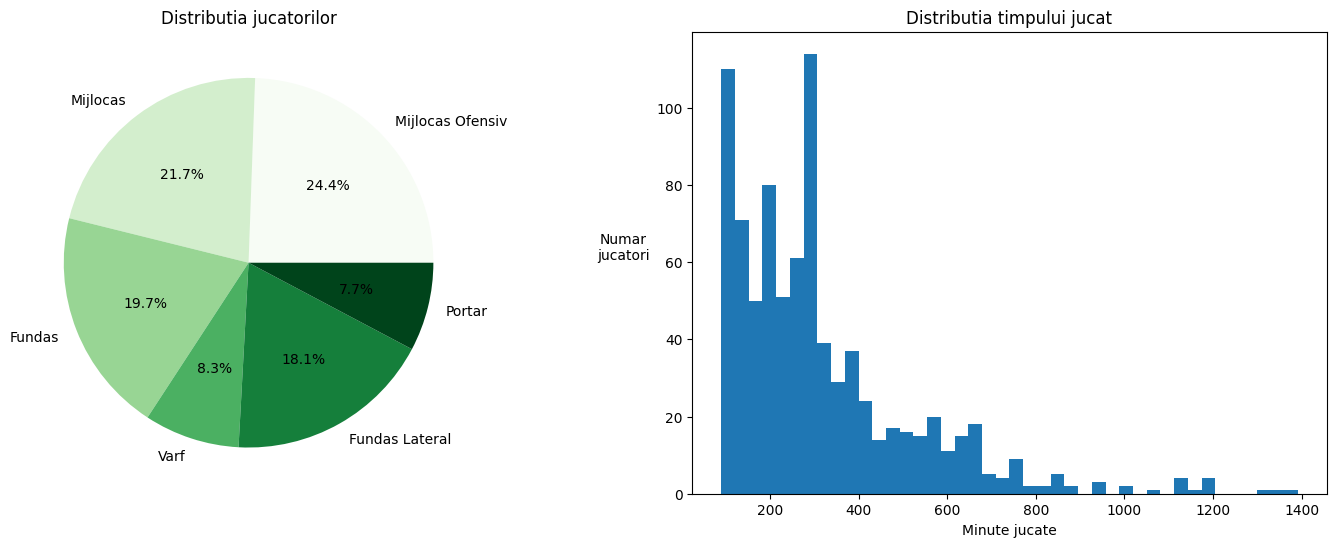

In [ ]:
# diagrame
import matplotlib.pyplot as plt
fig, (nrpos, mins) = plt.subplots(1, 2, figsize = (18, 6))

position_counts = dataset_final['target_position'].value_counts(normalize=True, sort=False)
position_counts.plot.pie(ax = nrpos, autopct = "%1.1f%%", cmap = 'Greens')
nrpos.set_ylabel('')
nrpos.set_title('Distributia jucatorilor')

mins.hist(dataset_final['minute_jucate'], bins = 42)
mins.set_xlabel('Minute jucate')
mins.set_ylabel('Numar\njucatori', rotation = 0, labelpad = 24)
mins.set_title('Distributia timpului jucat')

plt.show()

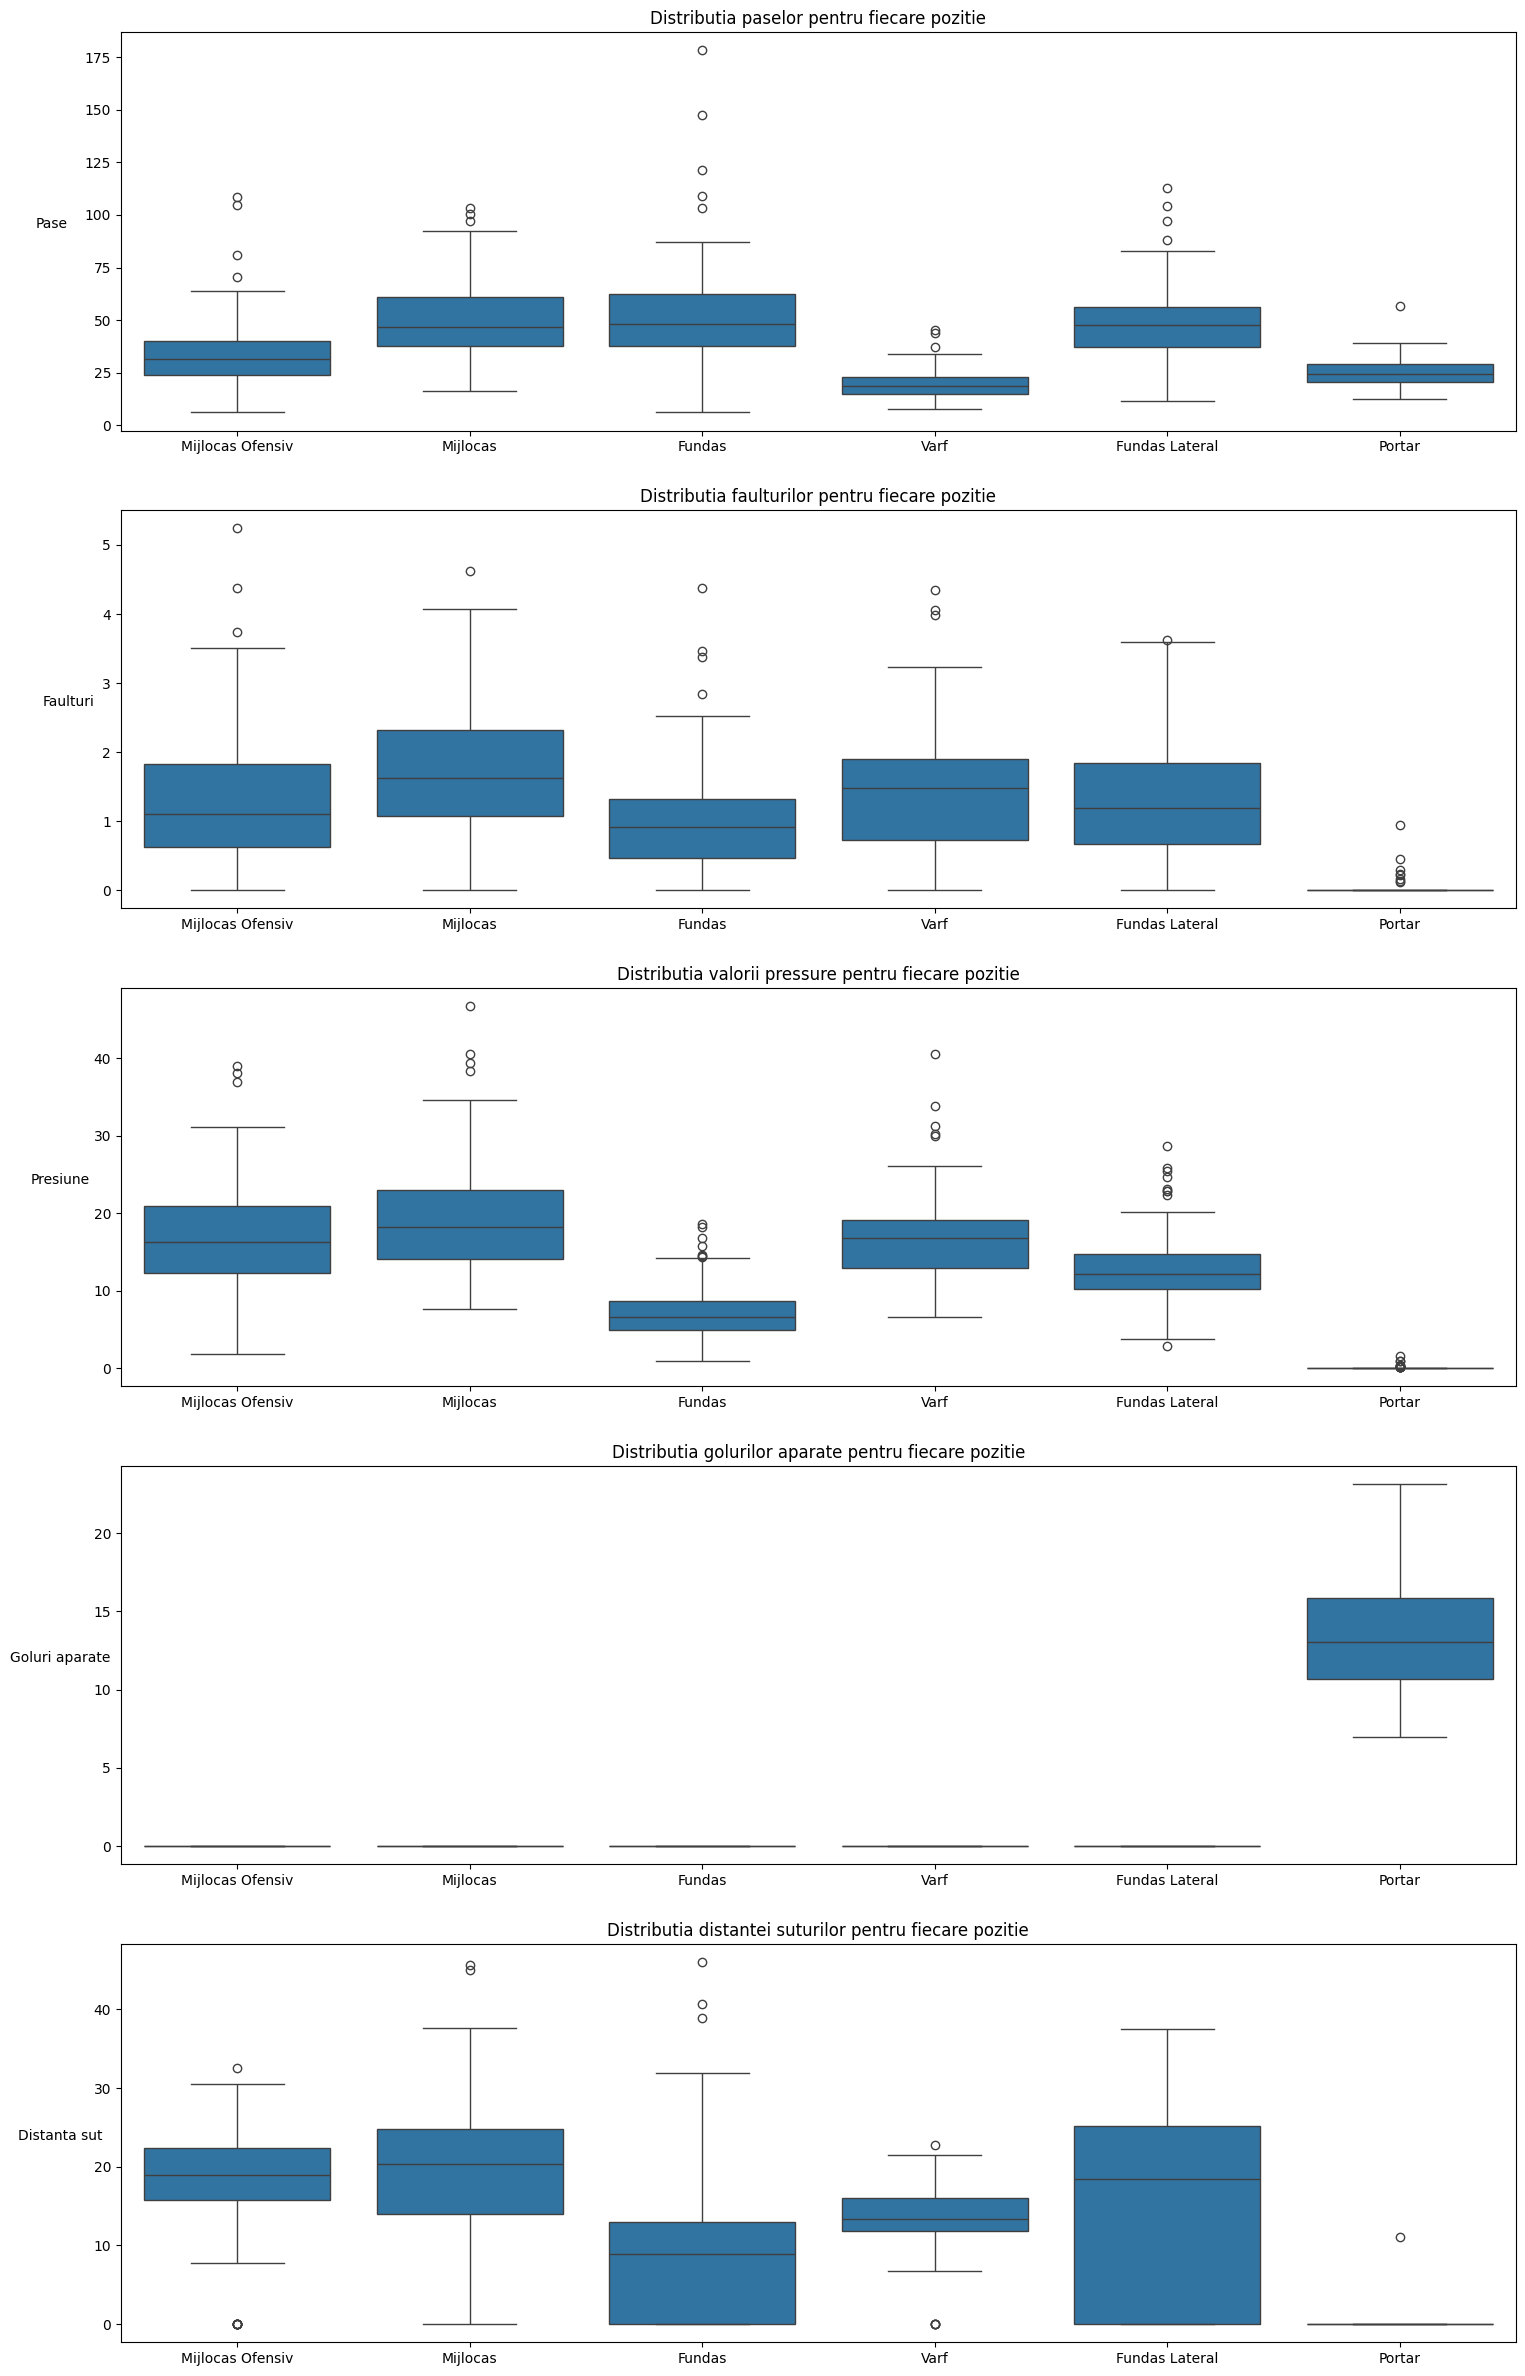

In [ ]:
# boxplots
import seaborn as sns
fig, (pase, faulturi, pressure, goluri_aparate, distanta_sut) = plt.subplots(5, figsize = (18, 30))

sns.boxplot(x = 'target_position', y = 'Pass_p90', data = dataset_final, ax = pase)
pase.set_title('Distributia paselor pentru fiecare pozitie')
pase.set_xlabel('')
pase.set_ylabel('Pase', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Foul Committed_p90', data = dataset_final, ax = faulturi)
faulturi.set_title('Distributia faulturilor pentru fiecare pozitie')
faulturi.set_xlabel('')
faulturi.set_ylabel('Faulturi', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Pressure_p90', data = dataset_final, ax = pressure)
pressure.set_title('Distributia valorii pressure pentru fiecare pozitie')
pressure.set_xlabel('')
pressure.set_ylabel('Presiune', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Goal Keeper_p90', data = dataset_final, ax = goluri_aparate)
goluri_aparate.set_title('Distributia golurilor aparate pentru fiecare pozitie')
goluri_aparate.set_xlabel('')
goluri_aparate.set_ylabel('Goluri aparate', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'avg_shot_distance', data = dataset_final, ax = distanta_sut)
distanta_sut.set_title('Distributia distantei suturilor pentru fiecare pozitie')
distanta_sut.set_xlabel('')
distanta_sut.set_ylabel('Distanta sut', rotation = 0, labelpad = 24)

plt.show()

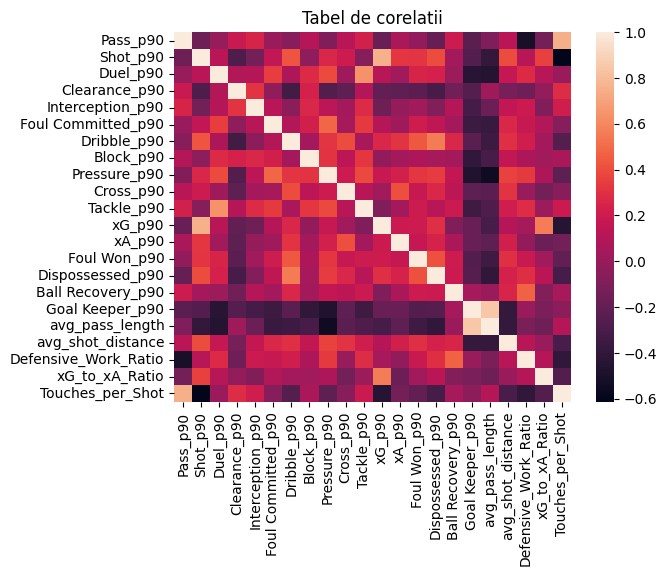

In [ ]:
# heatmap
coloane_caracteristici = [
    'Pass_p90', 'Shot_p90', 'Duel_p90', 'Clearance_p90', 'Interception_p90',
    'Foul Committed_p90', 'Dribble_p90', 'Block_p90',
    'Pressure_p90',
    'Cross_p90', 'Tackle_p90', 'xG_p90', 'xA_p90',
    'Foul Won_p90', 'Dispossessed_p90', 'Ball Recovery_p90',
    'Goal Keeper_p90',
    'avg_pass_length', 'avg_shot_distance',
    'Defensive_Work_Ratio', 'xG_to_xA_Ratio', 'Touches_per_Shot'
]
corelatie = dataset_final[coloane_caracteristici].corr()
sns.heatmap(data = corelatie)
plt.title('Tabel de corelatii')
plt.show()

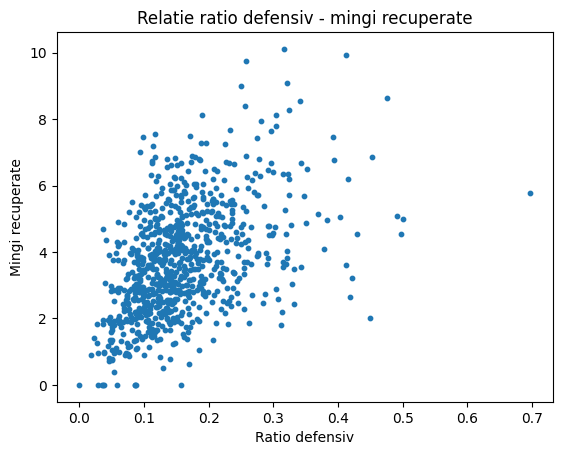

In [ ]:
# scatter plot
plt.scatter(x = dataset_final['Defensive_Work_Ratio'], y = dataset_final['Ball Recovery_p90'], s = 10)
plt.title('Relatie ratio defensiv - mingi recuperate')
plt.xlabel('Ratio defensiv')
plt.ylabel('Mingi recuperate')
plt.show()

In [ ]:
# alegerea coloanelor + train_test_split
from sklearn.model_selection import train_test_split
coloane_caracteristici = [
    'Pass_p90', 'Shot_p90', 'Duel_p90', 'Clearance_p90', 'Interception_p90',
    'Foul Committed_p90', 'Dribble_p90', 'Block_p90',
    'Pressure_p90',
    'Cross_p90', 'Tackle_p90', 'xG_p90', 'xA_p90',
    'Foul Won_p90', 'Dispossessed_p90', 'Ball Recovery_p90',
    'Goal Keeper_p90',
    'avg_pass_length', 'avg_shot_distance',
    'Defensive_Work_Ratio', 'xG_to_xA_Ratio', 'Touches_per_Shot'
]

X = dataset_final[coloane_caracteristici]
y = dataset_final['target_position']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

train_dataset = dataset_final.loc[X_train.index]
test_dataset = dataset_final.loc[X_test.index]

train_dataset.to_csv('train.csv', index=False)
test_dataset.to_csv('test.csv', index=False)

In [ ]:
X_train.describe()

,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,Foul Committed_p90,Dribble_p90,Block_p90,Pressure_p90,Cross_p90,...,xA_p90,Foul Won_p90,Dispossessed_p90,Ball Recovery_p90,Goal Keeper_p90,avg_pass_length,avg_shot_distance,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot
count,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,...,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000
mean,41.561278,1.024668,2.559370,1.544327,0.868382,1.222709,1.324225,1.526780,13.411295,1.019898,...,0.065366,1.157036,0.877462,3.694906,1.093458,21.306597,14.335453,0.155131,3.482196,28.093055
std,18.468554,1.065568,1.601086,1.690401,0.748512,0.918445,1.596417,1.018699,7.768646,1.297951,...,0.093237,1.042799,0.971043,1.649326,3.912978,7.839912,10.012640,0.074400,7.962664,16.934863
min,6.160000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10.880970,0.000000,0.000000,0.000000,3.313901
25%,27.875000,0.230000,1.580000,0.250000,0.270000,0.550000,0.135000,0.805000,7.865000,0.000000,...,0.000000,0.425000,0.000000,2.555000,0.000000,17.162357,7.010069,0.105823,0.000000,15.387273
50%,39.130000,0.730000,2.410000,0.950000,0.810000,1.100000,0.840000,1.480000,12.980000,0.580000,...,0.030000,0.930000,0.590000,3.600000,0.000000,19.422118,15.241913,0.140968,0.941176,25.222222
75%,53.230000,1.555000,3.500000,2.405000,1.310000,1.780000,1.885000,2.145000,18.190000,1.595000,...,0.095000,1.705000,1.360000,4.790000,0.000000,22.346022,21.725672,0.190702,3.000000,36.712644
max,121.420000,7.740000,11.610000,8.260000,4.170000,4.620000,10.880000,5.440000,46.680000,11.520000,...,0.950000,8.920000,5.270000,10.110000,23.120000,65.250049,45.694639,0.490872,94.000000,115.810000


In [ ]:
X_test.describe()

,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,Foul Committed_p90,Dribble_p90,Block_p90,Pressure_p90,Cross_p90,...,xA_p90,Foul Won_p90,Dispossessed_p90,Ball Recovery_p90,Goal Keeper_p90,avg_pass_length,avg_shot_distance,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,...,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,41.444841,1.069722,2.559325,1.489603,0.879444,1.285556,1.122103,1.557659,13.562024,1.035675,...,0.074563,1.119365,0.916548,3.776270,0.982063,21.160479,14.402828,0.164599,4.165440,28.434501
std,21.391328,1.133974,1.668997,1.582545,0.794103,0.968176,1.271768,1.131997,8.167227,1.306907,...,0.141307,1.005301,1.042282,1.696193,3.589866,7.207195,10.423800,0.092195,11.001061,20.962592
min,10.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10.722923,0.000000,0.017228,0.000000,1.942857
25%,25.972500,0.000000,1.457500,0.145000,0.172500,0.550000,0.000000,0.800000,8.247500,0.000000,...,0.000000,0.320000,0.000000,2.495000,0.000000,17.452322,0.000000,0.104117,0.000000,13.728842
50%,38.470000,0.700000,2.470000,0.990000,0.720000,1.130000,0.725000,1.345000,12.500000,0.455000,...,0.020000,0.935000,0.690000,3.665000,0.000000,19.605757,16.171923,0.147268,0.577381,24.159393
75%,51.812500,1.657500,3.492500,2.310000,1.335000,1.880000,1.650000,2.155000,18.195000,1.700000,...,0.092500,1.650000,1.435000,4.747500,0.000000,22.505884,22.180941,0.203841,4.000000,37.597988
max,178.120000,4.950000,8.330000,7.610000,3.870000,5.240000,7.570000,5.810000,40.560000,6.330000,...,1.030000,5.090000,6.080000,9.090000,21.470000,57.887048,46.010868,0.697396,90.000000,179.060000


                  precision    recall  f1-score   support

          Fundas       0.88      0.92      0.90        49
  Fundas Lateral       0.76      0.80      0.78        46
        Mijlocas       0.74      0.73      0.73        55
Mijlocas Ofensiv       0.71      0.68      0.69        62
          Portar       1.00      1.00      1.00        19
            Varf       0.60      0.57      0.59        21

        accuracy                           0.77       252
       macro avg       0.78      0.78      0.78       252
    weighted avg       0.77      0.77      0.77       252

Acuratete: 0.7738
Precizie: 0.7716
Recall: 0.7738
F1-Score: 0.7724



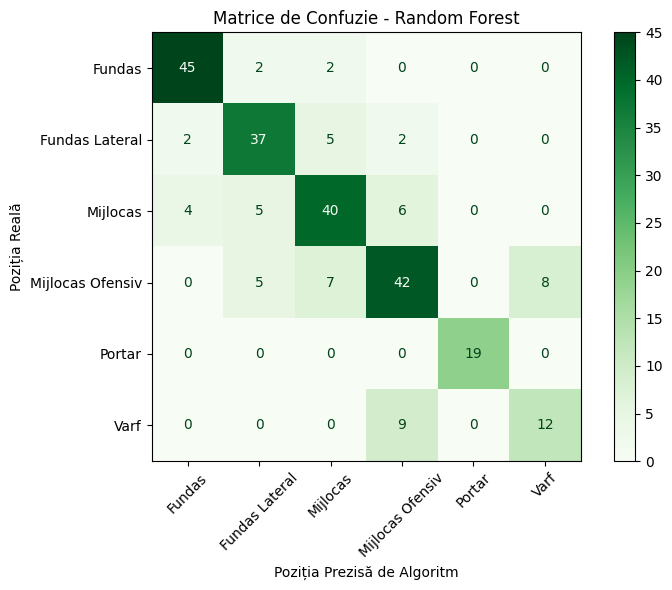

In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
RF = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=2, random_state=69 ,class_weight='balanced', max_features=5)
RF.fit(X_train, y_train)
y_pred_RF = RF.predict(X_test)
acuratete_RF = accuracy_score(y_test, y_pred_RF)
precizie_RF = precision_score(y_test, y_pred_RF, average='weighted', zero_division=0)
recall_RF = recall_score(y_test, y_pred_RF, average='weighted', zero_division=0)
f1_RF = f1_score(y_test, y_pred_RF, average='weighted', zero_division=0)

joblib.dump(RF, 'Position_Predictor.pkl')


print(classification_report(y_test, y_pred_RF))
print(f"Acuratete: {acuratete_RF:.4f}")
print(f"Precizie: {precizie_RF:.4f}")
print(f"Recall: {recall_RF:.4f}")
print(f"F1-Score: {f1_RF:.4f}\n")

cm_RF = confusion_matrix(y_test, y_pred_RF, labels=RF.classes_)
disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels=RF.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_RF.plot(cmap='Greens', ax=ax, xticks_rotation=45)
plt.title('Matrice de Confuzie - Random Forest')
plt.xlabel('Poziția Prezisă de Algoritm')
plt.ylabel('Poziția Reală')
plt.tight_layout()
plt.show()


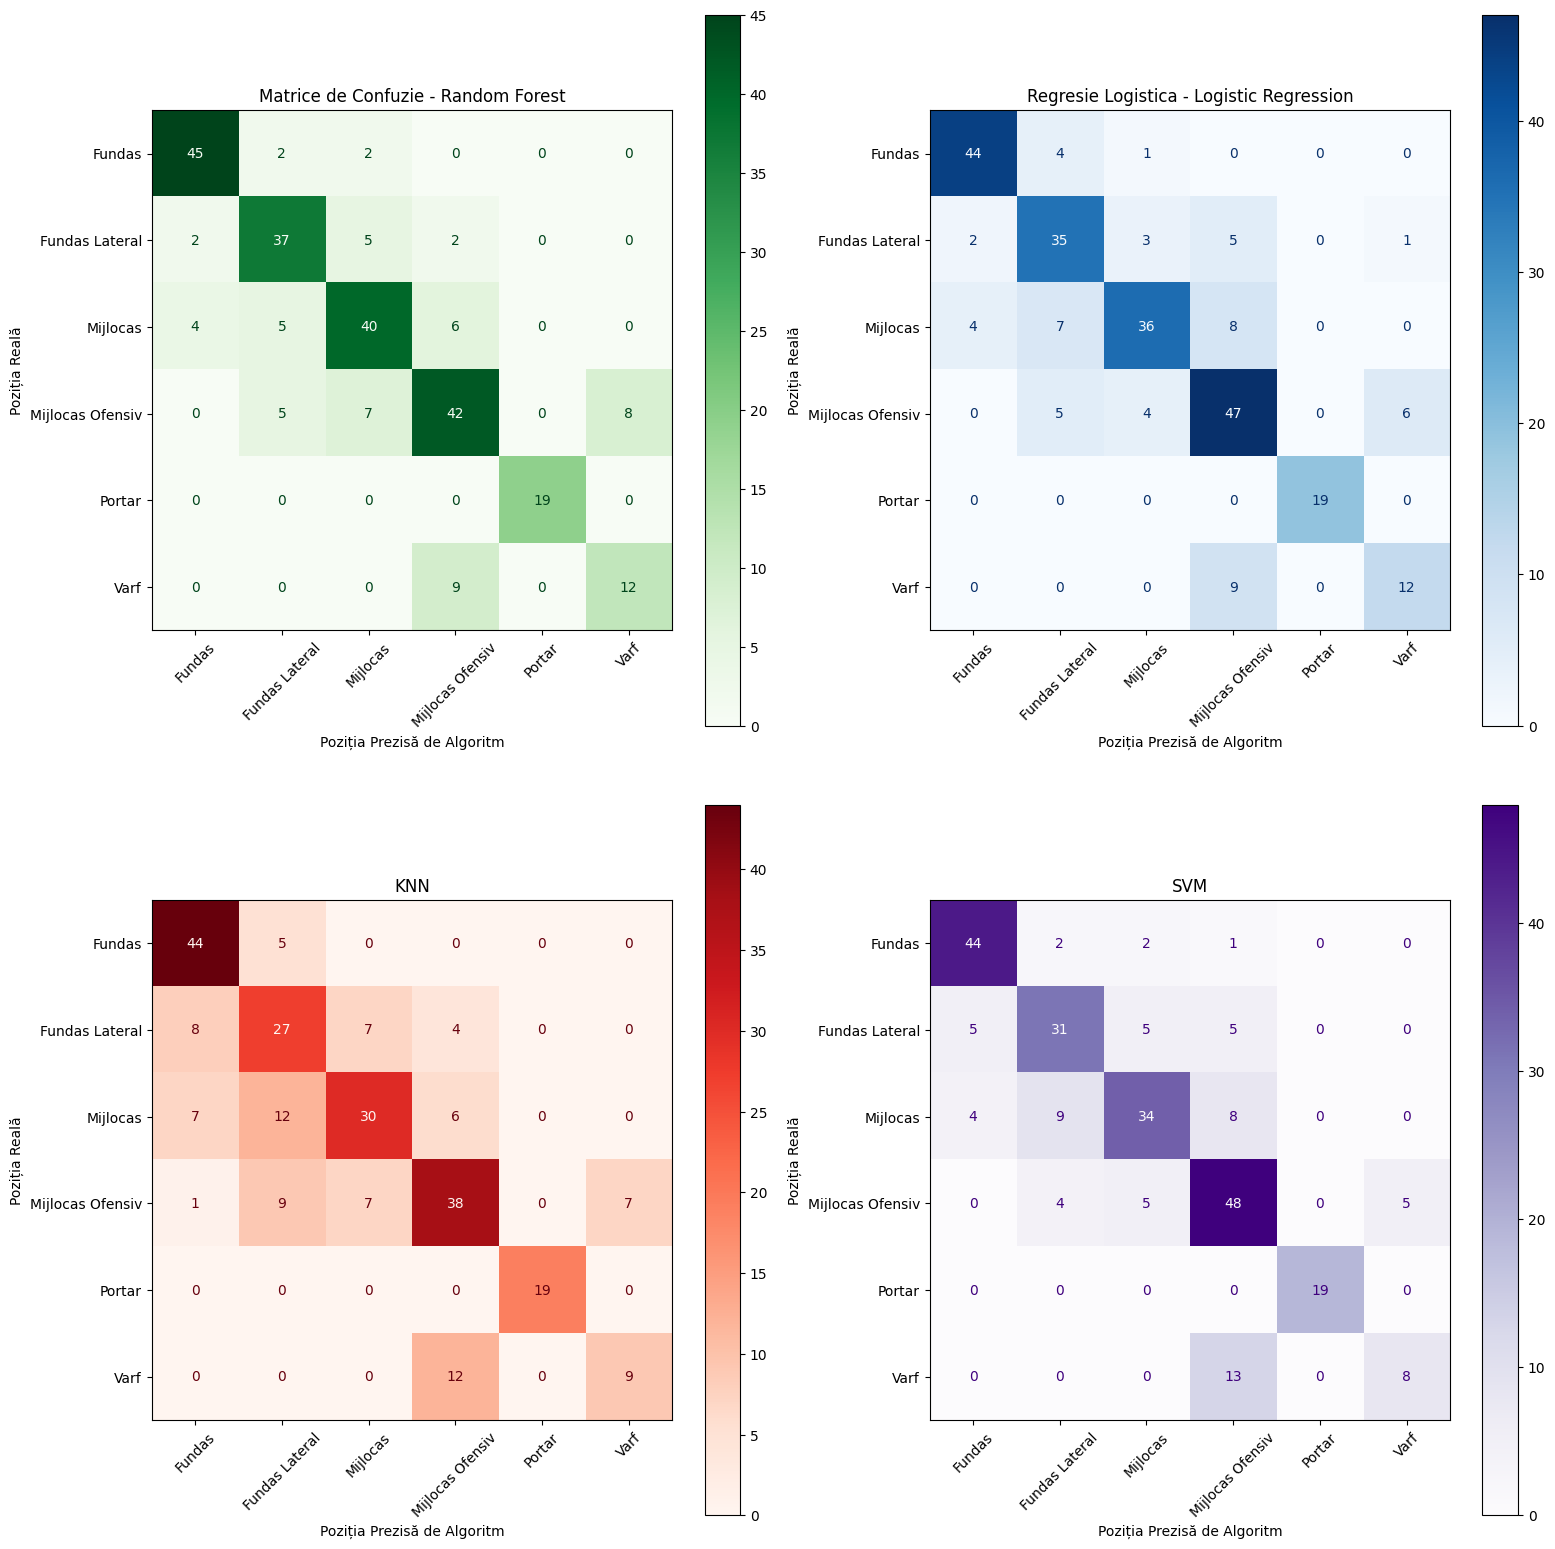

In [ ]:
# Comparatie intre 4 modele
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Random forest
RF = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=2, random_state=69 ,class_weight='balanced', max_features=5)
RF.fit(X_train, y_train)
y_pred_RF = RF.predict(X_test)
acuratete_RF = accuracy_score(y_test, y_pred_RF)
precizie_RF = precision_score(y_test, y_pred_RF, average='weighted', zero_division=0)
f1_RF = f1_score(y_test, y_pred_RF, average='weighted', zero_division=0)

scale = StandardScaler()
x_train_scaled = scale.fit_transform(X_train)
x_test_scaled = scale.transform(X_test)

train_scaled_df = pd.DataFrame(x_train_scaled)
test_scaled_df = pd.DataFrame(x_test_scaled)
train_scaled_df.to_csv('train_scaled.csv', index=False)
test_scaled_df.to_csv('test_scaled.csv', index=False)

# Logistic regression
LR = LogisticRegression(solver = 'lbfgs', random_state = 42)
LR.fit(x_train_scaled, y_train)

y_pred_LR = LR.predict(x_test_scaled)
acuratete_LR = accuracy_score(y_test, y_pred_LR)
precizie_LR = precision_score(y_test, y_pred_LR, average='weighted', zero_division=0)
f1_LR = f1_score(y_test, y_pred_LR, average='weighted', zero_division=0)

# KNN
KNN = KNeighborsClassifier(n_neighbors = 5)
KNN.fit(x_train_scaled, y_train)

y_pred_KNN = KNN.predict(x_test_scaled)
acuratete_KNN = accuracy_score(y_test, y_pred_KNN)
precizie_KNN = precision_score(y_test, y_pred_KNN, average='weighted', zero_division=0)
f1_KNN = f1_score(y_test, y_pred_KNN, average='weighted', zero_division=0)

#SVM
SVM = SVC(kernel = 'rbf', C = 1, gamma = 'scale', random_state = 42)
SVM.fit(x_train_scaled, y_train)

y_pred_SVM = SVM.predict(x_test_scaled)
acuratete_SVM = accuracy_score(y_test, y_pred_SVM)
precizie_SVM = precision_score(y_test, y_pred_SVM, average='weighted', zero_division=0)
f1_SVM = f1_score(y_test, y_pred_SVM, average='weighted', zero_division=0)

# Matrici de confuzie
cm_RF = confusion_matrix(y_test, y_pred_RF, labels=RF.classes_)
disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels=RF.classes_)

cm_LR = confusion_matrix(y_test, y_pred_LR, labels=LR.classes_)
disp_LR = ConfusionMatrixDisplay(confusion_matrix=cm_LR, display_labels=LR.classes_)

cm_KNN = confusion_matrix(y_test, y_pred_KNN, labels=KNN.classes_)
disp_KNN = ConfusionMatrixDisplay(confusion_matrix=cm_KNN, display_labels=KNN.classes_)

cm_SVM = confusion_matrix(y_test, y_pred_SVM, labels=SVM.classes_)
disp_SVM = ConfusionMatrixDisplay(confusion_matrix=cm_SVM, display_labels=SVM.classes_)

# Display
mat_conf, ((Rf, Lr), (Knn, Svm)) = plt.subplots(2, 2, figsize = (16, 16))

disp_RF.plot(cmap = 'Greens', ax = Rf, xticks_rotation = 45)
Rf.set_title('Matrice de Confuzie - Random Forest')
Rf.set_xlabel('Poziția Prezisă de Algoritm')
Rf.set_ylabel('Poziția Reală')

disp_LR.plot(cmap = 'Blues', ax = Lr, xticks_rotation = 45)
Lr.set_title('Regresie Logistica - Logistic Regression')
Lr.set_xlabel('Poziția Prezisă de Algoritm')
Lr.set_ylabel('Poziția Reală')

disp_KNN.plot(cmap = 'Reds', ax = Knn, xticks_rotation = 45)
Knn.set_title('KNN')
Knn.set_xlabel('Poziția Prezisă de Algoritm')
Knn.set_ylabel('Poziția Reală')

disp_SVM.plot(cmap = 'Purples', ax = Svm, xticks_rotation = 45)
Svm.set_title('SVM')
Svm.set_xlabel('Poziția Prezisă de Algoritm')
Svm.set_ylabel('Poziția Reală')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluare performanta
from tabulate import tabulate

tabel = [
    ['RF', acuratete_RF, f1_RF, precizie_RF],
    ['LR', acuratete_LR, f1_LR, precizie_LR],
    ['KNN', acuratete_KNN, f1_KNN, precizie_KNN],
    ['SVM', acuratete_SVM, f1_SVM, precizie_SVM]
]

print(tabulate(tabel, headers = ['Model', 'Acuratete', 'Scor F1', 'Precizie'], tablefmt = "grid"))

+---------+-------------+-----------+------------+
| Model   |   Acuratete |   Scor F1 |   Precizie |
+=========+=============+===========+============+
| RF      |    0.77381  |  0.772351 |   0.771612 |
+---------+-------------+-----------+------------+
| LR      |    0.765873 |  0.765238 |   0.77057  |
+---------+-------------+-----------+------------+
| KNN     |    0.662698 |  0.658028 |   0.662486 |
+---------+-------------+-----------+------------+
| SVM     |    0.730159 |  0.724729 |   0.729899 |
+---------+-------------+-----------+------------+


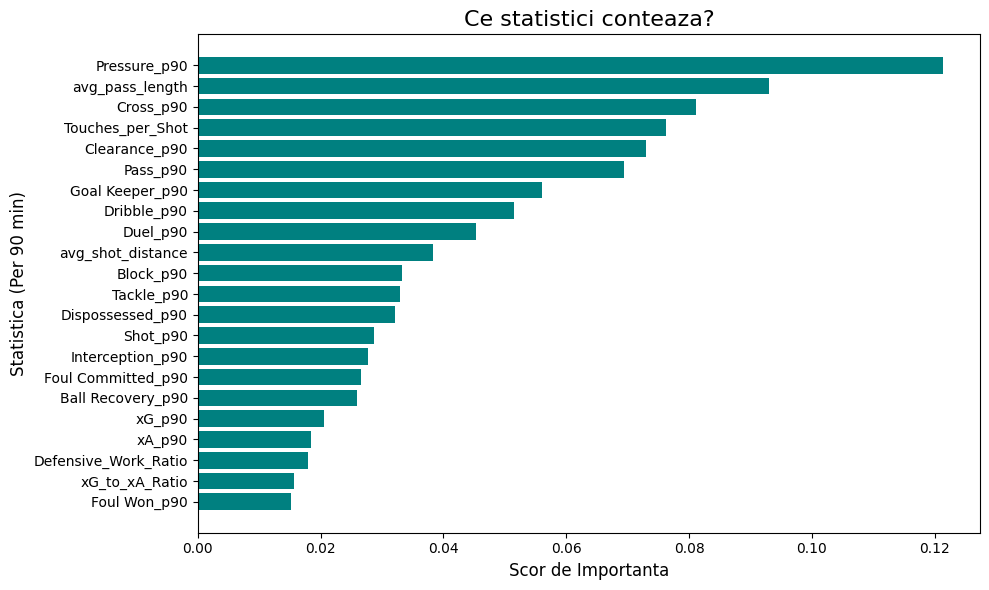

In [ ]:
importanta_caracteristici = RF.feature_importances_
tabel_importanta = pd.DataFrame({
    'Caracteristica': X_train.columns,
    'Importanta': importanta_caracteristici
})
tabel_importanta = tabel_importanta.sort_values(by='Importanta', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tabel_importanta['Caracteristica'], tabel_importanta['Importanta'], color='teal')

plt.title('Ce statistici conteaza?', fontsize=16)
plt.xlabel('Scor de Importanta', fontsize=12)
plt.ylabel('Statistica (Per 90 min)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# interfata grafica
import gradio as gr
import pandas as pd
import joblib

model_incarcat = joblib.load('Position_Predictor.pkl')

def prezice_pozitia(p, s, d, c, i, f, dr, b, pr, cr, t, xg, xa, fw, dp, br, gk, apl, asd):
    xGxA = xg / (xa + 0.01)
    dwr = (t + i + br) / (p + 1)
    tps = (p + dr + d) / (s + 1)
    date_jucator = pd.DataFrame({
        'Pass_p90': [p],
        'Shot_p90': [s],
        'Duel_p90': [d],
        'Clearance_p90': [c],
        'Interception_p90': [i],
        'Foul Committed_p90': [f],
        'Dribble_p90': [dr],
        'Block_p90': [b],
        'Pressure_p90': [pr],
        'Cross_p90': [cr],
        'Tackle_p90': [t],
        'xG_p90': [xg],
        'xA_p90': [xa],
        'Foul Won_p90': [fw],
        'Dispossessed_p90': [dp],
        'Ball Recovery_p90': [br],
        'Goal Keeper_p90': [gk],
        'avg_pass_length': [apl],
        'avg_shot_distance': [asd],
        'Defensive_Work_Ratio': [dwr],
        'xG_to_xA_Ratio': [xGxA],
        'Touches_per_Shot': [tps]
    })

    probabilitati = model_incarcat.predict_proba(date_jucator)[0]
    clase_pozitii = model_incarcat.classes_
    dict_probabilitati = {str(clase_pozitii[idx]): float(probabilitati[idx]) for idx in range(len(clase_pozitii))}

    return dict_probabilitati, round(dwr, 2), round(xGxA, 2), round(tps, 2)


intrari_interfata = [
    gr.Slider(minimum=0, maximum=150, step=0.1, label="Pase per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Suturi per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.05, label="Dueluri per 90"),
    gr.Slider(minimum=0, maximum=8, step=0.01, label="Degajari per 90"),
    gr.Slider(minimum=0, maximum=4, step=0.01, label="Interceptii per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Faulturi Comise per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Driblinguri per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Blocaje per 90"),
    gr.Slider(minimum=0, maximum=40, step=0.1, label="Pressinguri per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Centrari per 90"),
    gr.Slider(minimum=0, maximum=7, step=0.01, label="Tackle-uri per 90"),
    gr.Slider(minimum=0, maximum=1.5, step=0.01, label="xG per 90"),
    gr.Slider(minimum=0, maximum=1, step=0.01, label="xA per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Faulturi Castigate"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Deposedat"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Mingi Castigate"),
    gr.Slider(minimum=0, maximum=20, step=0.01, label="Statistici portar"),
    gr.Number(label="Distanta medie a pasei", value=20),
    gr.Number(label="Distanta medie a sutului", value=16),
    #gr.Number(label="Defensive Work Ratio", value=0.5),
    #gr.Number(label="xG to xA Ratio", value=1.0),
    #gr.Number(label="Atingeri per sut", value=40),
]

iesiri_interfata = [
    gr.Label(num_top_classes=3, label="Probabilitati Predictie"),
    gr.Number(label="Defensive Work Ratio"),
    gr.Number(label="xG to xA Ratio"),
    gr.Number(label="Atingeri per Sut")
]

aplicatie = gr.Interface(
    fn=prezice_pozitia,
    inputs=intrari_interfata,
    outputs=iesiri_interfata,
    title="Predictor pozitie jucatori",
    theme="default"
)

aplicatie.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0fe39e2f43b60dfc15.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
with gr.Blocks() as grafice:
  gr.Markdown('# Matriciile de confuzie')
  plot_output = gr.Plot(value = mat_conf)
grafice.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ea7d7d4fca6f7522f0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
